# Coevolution GA — Further Analysis

This notebook consolidates three scripts into a single reproducible workflow:

| Script | Purpose |
|---|---|
| `coevolution_ga.py` | Two-population coevolution GA (paths + rule-sets) with V10 binning |
| `run_coevolution_stability.py` | Run GA across 5 seeds and produce a stability report |
| `run_no_time.py` | Re-run GA without Time-based features and compare to baseline |

**Outputs produced** (saved to `outputs_no_time/`):
- `feature_list_no_time.json`, `thresholds_train_no_time.json`
- `pareto_front.csv`, `selected_operating_points.json`, `report.md`
- `stability_report.md`, `stability_metrics.csv`
- `plots/recall_vs_precision.png`, `plots/alert_rate_vs_precision.png`, `plots/alert_rate_vs_recall.png`
- `comparison_summary.md`, `comparison_table.csv`

---
## 1. Setup & Imports

Detect the repository root so that all helper modules (`coevolution_ga`, `rule_data`, `analyze_results`, etc.) are importable regardless of where this notebook is launched from.

In [1]:
import sys, os
from pathlib import Path

# Auto-detect repo root
_nb_dir = Path(os.getcwd())
_candidates = [_nb_dir, _nb_dir.parent, _nb_dir.parent.parent]
REPO_ROOT = None
for c in _candidates:
    if (c / "coevolution_ga.py").exists():
        REPO_ROOT = c
        break
if REPO_ROOT is None:
    REPO_ROOT = Path(r"C:\Users\mathu")  # fallback

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")
os.chdir(REPO_ROOT)

Repo root: c:\Users\mathu


In [2]:
import copy
import json
import re
import random
import shutil
import time
from types import SimpleNamespace
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

from deap import base, creator, tools

# Project modules
from rule_data import load_splits, load_thresholds
from analyze_results import (
    build_comparison_table,
    evaluate_selected_on_test,
    load_pareto_front,
    select_operating_points,
    write_report_md,
)
import coevolution_ga as coevo

print("All imports OK.")

All imports OK.


---
## 2. Configuration

All parameters are defined here as a `SimpleNamespace` (replacing `argparse` in the script versions). Adjust any value before running the cells below.

| Parameter | Default | Meaning |
|---|---|---|
| `alpha` | 0.01 | Maximum allowed alert rate |
| `min_tp_fitness` | 5 | Minimum true-positives on validation before a rule is viable |
| `max_nodes_per_path` | 5 | Max AND-conditions per rule (sponsor constraint) |
| `max_paths_per_ruleset` | 10 | Max OR-rules per rule-set |
| `budget_B` | 20 | Total condition budget across the entire rule-set |
| `seeds` | [11,22,33,44,55] | Random seeds for stability analysis |

In [3]:
DATA_DIR = REPO_ROOT / "artifacts" / "creditcard_prepared"
BASELINE_RESULTS_DIR = REPO_ROOT / "outputs" / "coevolution_rule_set_results_seeds"
OUTPUT_DIR = REPO_ROOT / "outputs_no_time"
SEEDS = [11, 22, 33, 44, 55]
EXCLUDE_FEATURES = {"Time", "Time_scaled", "Time_days"}

GA_PARAMS = SimpleNamespace(
    data_dir=str(DATA_DIR),
    output_dir=str(OUTPUT_DIR),
    seed=42,
    alpha=0.01,
    min_tp_fitness=5,
    max_nodes_per_path=5,
    max_paths_per_ruleset=10,
    budget_B=20,
    keep_raw_v10=False,
    exclude_features="",  # empty = include all
    path_pop_size=60,
    ruleset_pop_size=40,
    cycles=10,
    inner_path_gens=5,
    inner_ruleset_gens=5,
    path_cxpb=0.5,
    path_mutpb=0.4,
    ruleset_cxpb=0.6,
    ruleset_mutpb=0.4,
    path_hof_size=30,
    path_pop_cap=120,
    migrate_best_paths=5,
    migrate_best_rulesets=3,
)

print("Configuration ready.")
print(f"  Data dir:     {DATA_DIR}")
print(f"  Output dir:   {OUTPUT_DIR}")
print(f"  Baseline dir: {BASELINE_RESULTS_DIR}")
print(f"  Seeds:        {SEEDS}")
print(f"  Exclude:      {sorted(EXCLUDE_FEATURES)}")

Configuration ready.
  Data dir:     c:\Users\mathu\artifacts\creditcard_prepared
  Output dir:   c:\Users\mathu\outputs_no_time
  Baseline dir: c:\Users\mathu\outputs\coevolution_rule_set_results_seeds
  Seeds:        [11, 22, 33, 44, 55]
  Exclude:      ['Time', 'Time_days', 'Time_scaled']


---
## 3. Coevolution GA — How It Works

The coevolution GA uses **two co-evolving populations**:

1. **Paths** (Population A) — single AND-rules like `V14 < -1.2 AND V12 <= -0.5`  
   Fitness: F2 score (recall-weighted), capped by alert rate and minimum TP.

2. **Rule-sets** (Population B) — OR of multiple paths, e.g. `R1 | R2 | R3`  
   Fitness: multi-objective (maximize recall, maximize precision, minimize alert rate) using NSGA-II.

**Key features:**
- **Leakage-safe V10 binning**: decile edges fit on TRAIN only, applied via `pd.cut` to val/test.
- **Feature-type-aware operators**: `V10_bin_code` gets categorical ops (`=`, `>`, `<`, etc.); continuous features get (`>`, `>=`, `<`, `<=`).
- **Hard constraints**: max 5 conditions/path, max 10 paths/rule-set, total budget of 20 conditions.
- **Migration**: best paths are injected into rule-sets; best rule-set paths are promoted back.

### Running a single seed

The function `coevolution_ga.run_coevolution(args)` handles the full pipeline for one seed: data loading, V10 binning, GA evolution, Pareto extraction, operating-point selection, and report generation.

In [4]:
# Quick demo: run coevolution for a single seed (seed=42)
demo_dir = OUTPUT_DIR / "demo_single_seed"
demo_dir.mkdir(parents=True, exist_ok=True)

demo_args = SimpleNamespace(**vars(GA_PARAMS))
demo_args.seed = 42
demo_args.output_dir = str(demo_dir)

print(f"Running single-seed coevolution (seed={demo_args.seed}) ...")
demo_out = coevo.run_coevolution(demo_args)
print(f"\nDone. Pareto front: {demo_out['pareto_path']}")
print(f"Report: {demo_out['report_path']}")

Running single-seed coevolution (seed=42) ...
[cycle 1/10] best rs fitness=(recall=0.0845, precision=0.1132, alert=0.001245)
[cycle 2/10] best rs fitness=(recall=0.0845, precision=0.1132, alert=0.001245)
[cycle 3/10] best rs fitness=(recall=0.6761, precision=0.4324, alert=0.002608)
[cycle 4/10] best rs fitness=(recall=0.7324, precision=0.2031, alert=0.006015)
[cycle 5/10] best rs fitness=(recall=0.7324, precision=0.2031, alert=0.006015)
[cycle 6/10] best rs fitness=(recall=0.7887, precision=0.2074, alert=0.006344)
[cycle 7/10] best rs fitness=(recall=0.7887, precision=0.2074, alert=0.006344)
[cycle 8/10] best rs fitness=(recall=0.8169, precision=0.2071, alert=0.006579)
[cycle 9/10] best rs fitness=(recall=0.8169, precision=0.2071, alert=0.006579)
[cycle 10/10] best rs fitness=(recall=0.8169, precision=0.2180, alert=0.006250)

Done. Pareto front: c:\Users\mathu\outputs_no_time\demo_single_seed\pareto_front.csv
Report: c:\Users\mathu\outputs_no_time\demo_single_seed\report.md


In [5]:
# Show the Pareto front from the demo run
demo_pareto = pd.read_csv(demo_out["pareto_path"])
print(f"Pareto front: {len(demo_pareto)} points")
demo_pareto[["precision", "recall", "alert_rate", "n_rules", "total_conditions"]].head(10)

Pareto front: 36 points


,precision,recall,alert_rate,n_rules,total_conditions
0,0.218045,0.816901,0.006250,3,13
1,0.210728,0.774648,0.006133,3,13
2,0.210728,0.774648,0.006133,3,14
3,0.207692,0.760563,0.006109,3,14
4,0.207692,0.760563,0.006109,3,14
5,0.854839,0.746479,0.001457,1,4
6,0.859649,0.690141,0.001339,2,10
7,0.859649,0.690141,0.001339,3,14
8,0.859649,0.690141,0.001339,3,15
9,0.859649,0.690141,0.001339,3,15


---
## 4. Multi-Seed Stability Analysis

To show sponsors that results are not a one-off, we run the GA across **5 random seeds** (`11, 22, 33, 44, 55`). For each seed, we save the Pareto front and selected operating points, then compute:

- **Overlap**: how many unique rule-sets are selected across seeds
- **Variance**: mean ± std of precision, recall, and alert rate for each operating point

### 4a. Run coevolution for each seed (without Time exclusion first)

In [6]:
# Check if baseline stability results already exist
baseline_exists = all(
    (BASELINE_RESULTS_DIR / f"seed_{s}" / "pareto_front.csv").exists()
    for s in SEEDS
)

if baseline_exists:
    print("Baseline stability results already exist — skipping re-run.")
    print(f"  Location: {BASELINE_RESULTS_DIR}")
else:
    print("Running baseline coevolution across seeds (all features included) ...")
    BASELINE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    for seed in SEEDS:
        seed_dir = BASELINE_RESULTS_DIR / f"seed_{seed}"
        seed_dir.mkdir(parents=True, exist_ok=True)
        args_seed = SimpleNamespace(**vars(GA_PARAMS))
        args_seed.seed = seed
        args_seed.output_dir = str(seed_dir)
        args_seed.exclude_features = ""
        print(f"  seed={seed} ...", end=" ", flush=True)
        coevo.run_coevolution(args_seed)
        print("done.")
    print("Baseline runs complete.")

Baseline stability results already exist — skipping re-run.
  Location: c:\Users\mathu\outputs\coevolution_rule_set_results_seeds


### 4b. Stability helper functions

These functions (from `run_coevolution_stability.py`) compute overlap of selected rule-sets across seeds and summarise precision/recall/alert-rate distributions.

In [7]:
def load_selected_across_seeds(
    base_dir: Path, seeds: list
) -> Dict[int, Dict[str, Any]]:
    """Load selected_operating_points.json for each seed."""
    loaded = {}
    for seed in seeds:
        p = base_dir / f"seed_{seed}" / "selected_operating_points.json"
        if not p.exists():
            continue
        with p.open("r", encoding="utf-8") as f:
            raw = json.load(f)
        loaded[seed] = raw.get("operating_points", raw) if "operating_points" in raw else raw
    return loaded


def compute_stability_overlap(
    all_selected: Dict[int, Dict[str, Any]]
) -> Dict[str, Dict[str, Any]]:
    """Count unique rule-set strings per operating point across seeds."""
    points = ["conservative", "balanced", "aggressive"]
    overlap = {}
    for pt in points:
        counts = {}
        for seed, data in all_selected.items():
            op = data.get(pt)
            if not op:
                continue
            rule_str = op.get("rule_set_string", "")
            if rule_str:
                counts.setdefault(rule_str, []).append(seed)
        if not counts:
            overlap[pt] = {"unique_rule_sets": 0, "most_common_count": 0, "n_seeds": 0}
        else:
            overlap[pt] = {
                "unique_rule_sets": len(counts),
                "most_common_count": max(len(v) for v in counts.values()),
                "n_seeds": sum(len(v) for v in counts.values()),
            }
    return overlap


def compute_stability_metrics(
    all_selected: Dict[int, Dict[str, Any]]
) -> pd.DataFrame:
    """Compute mean/std/min/max of test metrics across seeds."""
    points = ["conservative", "balanced", "aggressive"]
    rows = []
    for pt in points:
        vals = [v[pt] for _, v in all_selected.items() if pt in v]
        if not vals:
            rows.append({"operating_point": pt, "n_seeds": 0,
                         "precision_mean": np.nan, "precision_std": np.nan,
                         "recall_mean": np.nan, "recall_std": np.nan,
                         "alert_rate_mean": np.nan, "alert_rate_std": np.nan})
            continue
        p = np.array([x["precision"] for x in vals])
        r = np.array([x["recall"] for x in vals])
        a = np.array([x["alert_rate"] for x in vals])
        rows.append({
            "operating_point": pt, "n_seeds": len(vals),
            "precision_mean": np.mean(p), "precision_std": np.std(p),
            "recall_mean": np.mean(r), "recall_std": np.std(r),
            "alert_rate_mean": np.mean(a), "alert_rate_std": np.std(a),
            "precision_min": np.min(p), "precision_max": np.max(p),
            "recall_min": np.min(r), "recall_max": np.max(r),
            "alert_rate_min": np.min(a), "alert_rate_max": np.max(a),
        })
    return pd.DataFrame(rows)


def write_stability_report(
    base_dir: Path, seeds: list,
    overlap: Dict[str, Dict[str, Any]],
    metrics_df: pd.DataFrame,
) -> Path:
    """Write stability_report.md and stability_metrics.csv."""
    metrics_df.to_csv(base_dir / "stability_metrics.csv", index=False)
    path = base_dir / "stability_report.md"
    with path.open("w", encoding="utf-8") as f:
        f.write("# Coevolution GA Stability Report\n\n")
        f.write(f"Seeds: {seeds}\n\n")
        f.write("## 1) Overlap of selected rule sets across seeds\n\n")
        for pt in ["conservative", "balanced", "aggressive"]:
            row = overlap.get(pt, {})
            f.write(f"### {pt.capitalize()}\n")
            f.write(f"- Unique rule sets: **{row.get('unique_rule_sets', 0)}**\n")
            f.write(f"- Most common frequency: **{row.get('most_common_count', 0)}**\n\n")
        f.write("## 2) Variance in precision / recall / alert_rate (TEST)\n\n")
        try:
            f.write(metrics_df.to_markdown(index=False))
        except AttributeError:
            f.write(metrics_df.to_string(index=False))
        f.write("\n")
    return path

print("Stability helper functions defined.")

Stability helper functions defined.


### 4c. Compute baseline stability

Load the per-seed selected operating points from the baseline run (with all features) and show the stability summary.

In [8]:
baseline_all = load_selected_across_seeds(BASELINE_RESULTS_DIR, SEEDS)
print(f"Loaded baseline results for {len(baseline_all)} seeds.")

baseline_overlap = compute_stability_overlap(baseline_all)
baseline_metrics = compute_stability_metrics(baseline_all)

print("\nBaseline stability metrics:")
baseline_metrics

Loaded baseline results for 5 seeds.

Baseline stability metrics:


,operating_point,n_seeds,precision_mean,precision_std,recall_mean,recall_std,alert_rate_mean,alert_rate_std,precision_min,precision_max,recall_min,recall_max,alert_rate_min,alert_rate_max
0,conservative,4,0.528571,0.313310,0.084507,0.085092,0.000188,0.000173,0.000000,0.800000,0.000000,0.225352,0.000000,0.000470
1,balanced,5,0.737387,0.076735,0.732394,0.025195,0.001673,0.000160,0.595238,0.797101,0.704225,0.774648,0.001504,0.001974
2,aggressive,5,0.374440,0.250520,0.760563,0.045421,0.005150,0.002849,0.137845,0.796875,0.704225,0.830986,0.001504,0.009375


---
## 5. Excluding Time Features

Time-based features (`Time`, `Time_scaled`, `Time_days`) encode the **absolute transaction timestamp** within the dataset. Rules that use these features are dataset-specific and won't generalize to new data collected at different times.

This section:
1. Creates a filtered feature list and threshold bank (excluding Time features)
2. Re-runs the coevolution GA across 5 seeds using only the non-Time features
3. Produces the same stability analysis for comparison

### 5a. Filter features and thresholds

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Filter feature list
with (DATA_DIR / "feature_list.json").open("r", encoding="utf-8") as f:
    all_features = json.load(f)
filtered_features = [feat for feat in all_features if feat not in EXCLUDE_FEATURES]

with (OUTPUT_DIR / "feature_list_no_time.json").open("w", encoding="utf-8") as f:
    json.dump(filtered_features, f, indent=2)

print(f"Feature list: {len(all_features)} -> {len(filtered_features)}")
print(f"Removed: {sorted(set(all_features) - set(filtered_features))}")

# Filter thresholds
with (DATA_DIR / "thresholds_train.json").open("r", encoding="utf-8") as f:
    all_thresholds = json.load(f)
filtered_thresholds = {k: v for k, v in all_thresholds.items() if k not in EXCLUDE_FEATURES}

with (OUTPUT_DIR / "thresholds_train_no_time.json").open("w", encoding="utf-8") as f:
    json.dump(filtered_thresholds, f, indent=2)

print(f"Thresholds:   {len(all_thresholds)} -> {len(filtered_thresholds)}")

Feature list: 34 -> 31
Removed: ['Time', 'Time_days', 'Time_scaled']
Thresholds:   34 -> 31


### 5b. Run coevolution without Time features (5 seeds)

Each seed runs the full coevolution pipeline with `--exclude_features Time,Time_scaled,Time_days`. The GA will never see or select these features during condition generation or mutation.

In [10]:
stability_dir = OUTPUT_DIR / "stability_seeds"
stability_dir.mkdir(parents=True, exist_ok=True)

exclude_csv = ",".join(sorted(EXCLUDE_FEATURES))

for seed in SEEDS:
    seed_dir = stability_dir / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    args_seed = SimpleNamespace(**vars(GA_PARAMS))
    args_seed.seed = seed
    args_seed.output_dir = str(seed_dir)
    args_seed.exclude_features = exclude_csv

    print(f"Seed {seed} ...", end=" ", flush=True)
    coevo.run_coevolution(args_seed)
    print("done.")

print(f"\nAll {len(SEEDS)} seeds complete. Outputs under: {stability_dir}")

Seed 11 ... [cycle 1/10] best rs fitness=(recall=0.0000, precision=0.0000, alert=1.000000)
[cycle 2/10] best rs fitness=(recall=0.3803, precision=0.5400, alert=0.001175)
[cycle 3/10] best rs fitness=(recall=0.7887, precision=0.4444, alert=0.002961)
[cycle 4/10] best rs fitness=(recall=0.7887, precision=0.4444, alert=0.002961)
[cycle 5/10] best rs fitness=(recall=0.7887, precision=0.4553, alert=0.002890)
[cycle 6/10] best rs fitness=(recall=0.7887, precision=0.4553, alert=0.002890)
[cycle 7/10] best rs fitness=(recall=0.7887, precision=0.4553, alert=0.002890)
[cycle 8/10] best rs fitness=(recall=0.7887, precision=0.7273, alert=0.001809)
[cycle 9/10] best rs fitness=(recall=0.7887, precision=0.7467, alert=0.001762)
[cycle 10/10] best rs fitness=(recall=0.7887, precision=0.7568, alert=0.001739)
done.
Seed 22 ... [cycle 1/10] best rs fitness=(recall=0.3380, precision=0.0930, alert=0.006062)
[cycle 2/10] best rs fitness=(recall=0.5070, precision=0.3871, alert=0.002185)
[cycle 3/10] best rs 

### 5c. Compute no-Time stability metrics

In [11]:
notime_all = load_selected_across_seeds(stability_dir, SEEDS)
print(f"Loaded no-Time results for {len(notime_all)} seeds.")

notime_overlap = compute_stability_overlap(notime_all)
notime_metrics = compute_stability_metrics(notime_all)

stab_report_path = write_stability_report(
    stability_dir, SEEDS, notime_overlap, notime_metrics
)
print(f"Stability report: {stab_report_path}")

# Copy to top-level output dir
for name in ("stability_report.md", "stability_metrics.csv"):
    src = stability_dir / name
    if src.exists():
        shutil.copy2(src, OUTPUT_DIR / name)

print("\nNo-Time stability metrics:")
notime_metrics

Loaded no-Time results for 5 seeds.
Stability report: c:\Users\mathu\outputs_no_time\stability_seeds\stability_report.md

No-Time stability metrics:


,operating_point,n_seeds,precision_mean,precision_std,recall_mean,recall_std,alert_rate_mean,alert_rate_std,precision_min,precision_max,recall_min,recall_max,alert_rate_min,alert_rate_max
0,conservative,4,0.679247,0.162306,0.204225,0.122988,0.000458,0.000190,0.444444,0.903226,0.056338,0.394366,0.000211,0.000728
1,balanced,5,0.734129,0.081227,0.723944,0.042347,0.001664,0.000187,0.576471,0.797101,0.676056,0.774648,0.001480,0.001997
2,aggressive,5,0.493631,0.221775,0.752113,0.032850,0.003421,0.002117,0.170418,0.797101,0.690141,0.774648,0.001621,0.007308


---
## 6. Step-3 Analysis & Visualization

Generate the standard Step-3 outputs from the best no-Time seed:
- **Pareto front CSV** with all non-dominated rule-sets
- **Selected operating points** (conservative / balanced / aggressive) evaluated on the TEST split
- **report.md** summarising the selected points
- **Scatter plots** of the Pareto front

### Operating point selection criteria

| Point | Objective | Alert rate cap | Support constraint |
|---|---|---|---|
| Conservative | max precision | ≤ 0.05% | val TP ≥ 5 |
| Balanced | max F2 | ≤ 0.2% | val TP ≥ 10 |
| Aggressive | max recall | ≤ 1.0% | val precision ≥ 0.1 |

In [12]:
# Pick the first seed's pareto front as the representative
best_seed_dir = None
for s in SEEDS:
    d = stability_dir / f"seed_{s}"
    if (d / "pareto_front.csv").exists():
        best_seed_dir = d
        break

assert best_seed_dir is not None, "No pareto_front.csv found in any seed directory."

# Copy pareto front to top-level output dir
shutil.copy2(best_seed_dir / "pareto_front.csv", OUTPUT_DIR / "pareto_front.csv")

# Load and select operating points
pareto = load_pareto_front(OUTPUT_DIR / "pareto_front.csv")
_, _, X_val, y_val, X_test, y_test = load_splits(DATA_DIR)

selected = select_operating_points(pareto, X_val=X_val, y_val=y_val)
selected_test = evaluate_selected_on_test(selected, X_test, y_test)

# Save
with (OUTPUT_DIR / "selected_operating_points.json").open("w", encoding="utf-8") as f:
    json.dump(selected_test, f, indent=2)

comparison_df = build_comparison_table(selected_test)
write_report_md(OUTPUT_DIR, comparison_df)

print("Selected operating points (TEST split):")
comparison_df

Selected operating points (TEST split):


,operating_point,precision,recall,alert_rate,tp,fp,fn,tn,n_rules,total_conditions
0,conservative,0.681818,0.211268,0.000517,15,7,56,42481,1,5
1,balanced,0.753425,0.774648,0.001715,55,18,16,42470,2,10
2,aggressive,0.604396,0.774648,0.002138,55,36,16,42452,2,10


### 6a. Pareto front plots

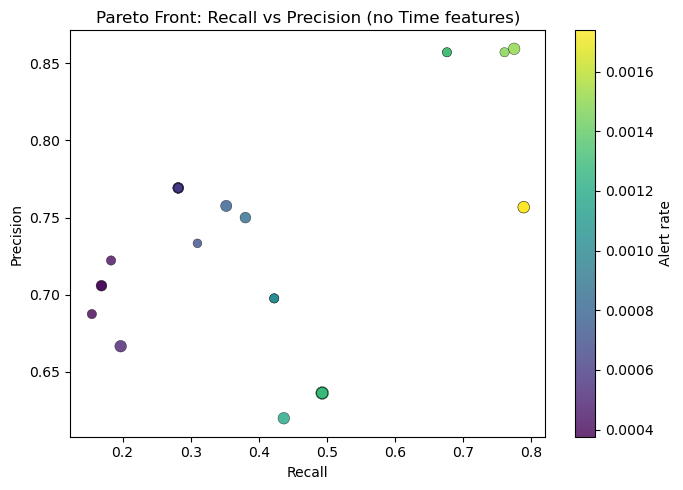

In [13]:
plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

df_plot = pd.read_csv(OUTPUT_DIR / "pareto_front.csv")

# Plot 1: Recall vs Precision
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    df_plot["recall"], df_plot["precision"],
    c=df_plot["alert_rate"], s=20 + 5 * df_plot["total_conditions"],
    cmap="viridis", alpha=0.8, edgecolors="k", linewidths=0.3,
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Pareto Front: Recall vs Precision (no Time features)")
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Alert rate")
fig.tight_layout()
fig.savefig(plots_dir / "recall_vs_precision.png", dpi=150)
plt.show()

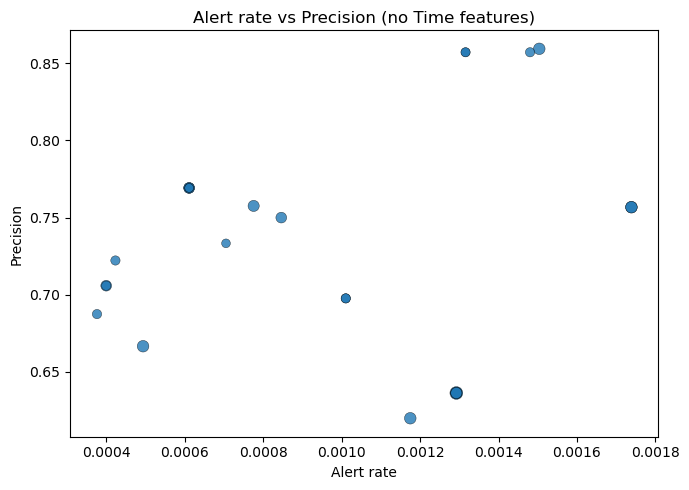

In [14]:
# Plot 2: Alert rate vs Precision
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_plot["alert_rate"], df_plot["precision"],
    s=20 + 5 * df_plot["total_conditions"], alpha=0.8,
    edgecolors="k", linewidths=0.3,
)
ax.set_xlabel("Alert rate")
ax.set_ylabel("Precision")
ax.set_title("Alert rate vs Precision (no Time features)")
fig.tight_layout()
fig.savefig(plots_dir / "alert_rate_vs_precision.png", dpi=150)
plt.show()

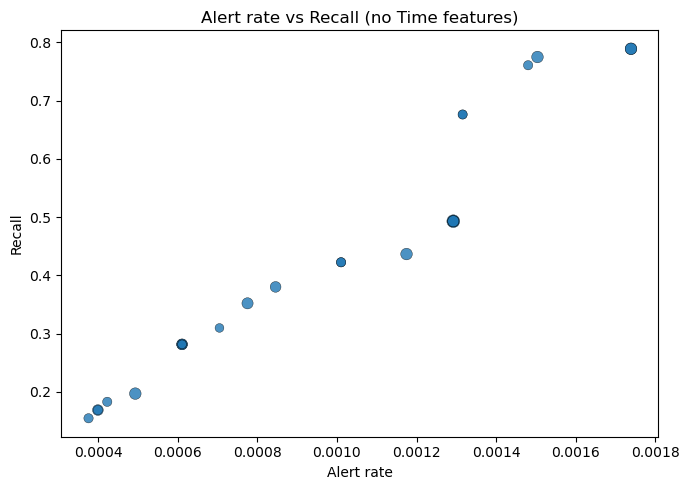

In [15]:
# Plot 3: Alert rate vs Recall
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_plot["alert_rate"], df_plot["recall"],
    s=20 + 5 * df_plot["total_conditions"], alpha=0.8,
    edgecolors="k", linewidths=0.3,
)
ax.set_xlabel("Alert rate")
ax.set_ylabel("Recall")
ax.set_title("Alert rate vs Recall (no Time features)")
fig.tight_layout()
fig.savefig(plots_dir / "alert_rate_vs_recall.png", dpi=150)
plt.show()

---
## 7. Verification — No Time Features in Output Rules

Scan every `pareto_front.csv` and `selected_operating_points.json` under `outputs_no_time/` to confirm that **none** of the excluded features appear in any rule string.

In [16]:
patterns = {feat: re.compile(r"\b" + re.escape(feat) + r"\b") for feat in EXCLUDE_FEATURES}
leak_found = False

for csv_file in OUTPUT_DIR.rglob("pareto_front.csv"):
    df_check = pd.read_csv(csv_file)
    if "rule_set_string" not in df_check.columns:
        continue
    for _, row in df_check.iterrows():
        for feat, pat in patterns.items():
            if pat.search(str(row["rule_set_string"])):
                print(f"LEAK: {feat} found in {csv_file}")
                leak_found = True

for json_file in OUTPUT_DIR.rglob("selected_operating_points.json"):
    text = json_file.read_text(encoding="utf-8")
    for feat, pat in patterns.items():
        if pat.search(text):
            print(f"LEAK: {feat} found in {json_file}")
            leak_found = True

if not leak_found:
    print("PASS: No excluded features found in any output rule strings.")
else:
    print("WARNING: Excluded features detected in outputs — investigate above.")

LEAK: Time_scaled found in c:\Users\mathu\outputs_no_time\demo_single_seed\pareto_front.csv
LEAK: Time_scaled found in c:\Users\mathu\outputs_no_time\demo_single_seed\pareto_front.csv


---
## 8. Comparison: Baseline (with Time) vs No-Time

Compare the selected operating points from the **baseline** run (all features, including Time) against the **no-Time** run. This tells us whether Time-based rules were adding genuine fraud signal or just dataset-specific noise.

In [17]:
def find_selected_json(directory: Path) -> Dict[str, Any]:
    """Search a directory (and seed_XX subfolders) for operating-point JSON."""
    for name in ("selected_operating_points.json", "selected_rule_sets.json"):
        p = directory / name
        if p.exists():
            with p.open("r", encoding="utf-8") as f:
                raw = json.load(f)
            return raw.get("operating_points", raw) if "operating_points" in raw else raw
    for sub in sorted(directory.glob("seed_*")):
        for name in ("selected_operating_points.json", "selected_rule_sets.json"):
            p = sub / name
            if p.exists():
                with p.open("r", encoding="utf-8") as f:
                    raw = json.load(f)
                return raw.get("operating_points", raw) if "operating_points" in raw else raw
    return {}


baseline_sel = find_selected_json(BASELINE_RESULTS_DIR)
notime_sel = find_selected_json(OUTPUT_DIR)

comp_rows = []
for pt in ["conservative", "balanced", "aggressive"]:
    b = baseline_sel.get(pt, {})
    n = notime_sel.get(pt, {})
    comp_rows.append({
        "operating_point": pt,
        "baseline_precision": b.get("precision", np.nan),
        "baseline_recall": b.get("recall", np.nan),
        "baseline_alert_rate": b.get("alert_rate", np.nan),
        "baseline_total_cond": b.get("total_conditions", ""),
        "notime_precision": n.get("precision", np.nan),
        "notime_recall": n.get("recall", np.nan),
        "notime_alert_rate": n.get("alert_rate", np.nan),
        "notime_total_cond": n.get("total_conditions", ""),
    })

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(OUTPUT_DIR / "comparison_table.csv", index=False)

print("Operating Point Comparison (TEST split):")
comp_df

Operating Point Comparison (TEST split):


,operating_point,baseline_precision,baseline_recall,baseline_alert_rate,baseline_total_cond,notime_precision,notime_recall,notime_alert_rate,notime_total_cond
0,conservative,NaN,NaN,NaN,,0.681818,0.211268,0.000517,5
1,balanced,0.718310,0.718310,0.001668,13,0.753425,0.774648,0.001715,10
2,aggressive,0.227799,0.830986,0.006086,12,0.604396,0.774648,0.002138,10


In [18]:
# Stability comparison (if both have stability_metrics.csv)
def load_stability_csv(directory: Path) -> pd.DataFrame:
    for sub in [directory, directory / "stability_seeds"]:
        p = sub / "stability_metrics.csv"
        if p.exists():
            return pd.read_csv(p)
    return None

baseline_stab = load_stability_csv(BASELINE_RESULTS_DIR)
notime_stab = load_stability_csv(OUTPUT_DIR)

if baseline_stab is not None and notime_stab is not None:
    stab_merged = baseline_stab.merge(
        notime_stab, on="operating_point",
        suffixes=("_baseline", "_notime"), how="outer",
    )
    print("Stability Comparison (mean ± std across seeds):")
    display(stab_merged)
else:
    stab_merged = None
    print("Stability metrics not available for both runs.")

Stability Comparison (mean ± std across seeds):


,operating_point,n_seeds_baseline,precision_mean_baseline,precision_std_baseline,recall_mean_baseline,recall_std_baseline,alert_rate_mean_baseline,alert_rate_std_baseline,precision_min_baseline,precision_max_baseline,...,recall_mean_notime,recall_std_notime,alert_rate_mean_notime,alert_rate_std_notime,precision_min_notime,precision_max_notime,recall_min_notime,recall_max_notime,alert_rate_min_notime,alert_rate_max_notime
0,aggressive,5,0.374440,0.250520,0.760563,0.045421,0.005150,0.002849,0.137845,0.796875,...,0.752113,0.032850,0.003421,0.002117,0.170418,0.797101,0.690141,0.774648,0.001621,0.007308
1,balanced,5,0.737387,0.076735,0.732394,0.025195,0.001673,0.000160,0.595238,0.797101,...,0.723944,0.042347,0.001664,0.000187,0.576471,0.797101,0.676056,0.774648,0.001480,0.001997
2,conservative,4,0.528571,0.313310,0.084507,0.085092,0.000188,0.000173,0.000000,0.800000,...,0.204225,0.122988,0.000458,0.000190,0.444444,0.903226,0.056338,0.394366,0.000211,0.000728


In [19]:
# Write comparison_summary.md
md_path = OUTPUT_DIR / "comparison_summary.md"
with md_path.open("w", encoding="utf-8") as f:
    f.write("# Comparison: With Time vs Without Time Features\n\n")
    f.write("## Operating Point Metrics (TEST split)\n\n")
    try:
        f.write(comp_df.to_markdown(index=False))
    except AttributeError:
        f.write(comp_df.to_string(index=False))
    f.write("\n\n")

    if stab_merged is not None:
        f.write("## Stability Comparison (mean +/- std across seeds)\n\n")
        try:
            f.write(stab_merged.to_markdown(index=False))
        except AttributeError:
            f.write(stab_merged.to_string(index=False))
        f.write("\n\n")

    # Determine if changes are material (>5pp shift)
    material = False
    for _, row in comp_df.iterrows():
        bp = row.get("baseline_precision", np.nan)
        np_ = row.get("notime_precision", np.nan)
        br = row.get("baseline_recall", np.nan)
        nr = row.get("notime_recall", np.nan)
        if pd.notna(bp) and pd.notna(np_) and abs(bp - np_) > 0.05:
            material = True
        if pd.notna(br) and pd.notna(nr) and abs(br - nr) > 0.05:
            material = True

    f.write("## Conclusion\n\n")
    if material:
        f.write(
            "Removing Time features caused **material changes** (>5pp shift in precision or recall "
            "for at least one operating point). Review the table above to decide whether "
            "Time-based rules were adding signal or just noise.\n"
        )
        conclusion_text = "MATERIAL CHANGES detected."
    else:
        f.write(
            "Removing Time features caused **no material change** (<5pp shift in all metrics). "
            "This confirms that Time-based rules were not contributing meaningful fraud signal "
            "and can be safely excluded to improve rule generalizability.\n"
        )
        conclusion_text = "No material change — Time features can be safely excluded."

print(f"Comparison summary written to: {md_path}")
print(f"Conclusion: {conclusion_text}")

Comparison summary written to: c:\Users\mathu\outputs_no_time\comparison_summary.md
Conclusion: MATERIAL CHANGES detected.


---
## 9. Output Summary

All outputs have been generated under `outputs_no_time/`. Here is the complete file listing.

In [20]:
print(f"Output directory: {OUTPUT_DIR}\n")
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        rel = p.relative_to(OUTPUT_DIR)
        size_kb = p.stat().st_size / 1024
        print(f"  {str(rel):<60s}  {size_kb:>8.1f} KB")

Output directory: c:\Users\mathu\outputs_no_time

  comparison_summary.md                                              4.6 KB
  comparison_table.csv                                               0.5 KB
  demo_single_seed\pareto_front.csv                                 15.3 KB
  demo_single_seed\report.md                                         0.9 KB
  demo_single_seed\run_log.json                                      0.8 KB
  demo_single_seed\selected_operating_points.json                    1.4 KB
  feature_list_no_time.json                                          0.3 KB
  pareto_front.csv                                                   9.1 KB
  plots\alert_rate_vs_precision.png                                 36.6 KB
  plots\alert_rate_vs_recall.png                                    35.2 KB
  plots\recall_vs_precision.png                                     52.4 KB
  report.md                                                          0.9 KB
  selected_operating_points.json      

---
## 10. How to Reproduce from CLI

The same results can be produced from the command line without this notebook:

```bash
# Full run (all 5 seeds + step-3 + comparison)
python run_no_time.py

# Or with custom parameters:
python run_no_time.py \
    --data_dir artifacts/creditcard_prepared \
    --out_dir outputs_no_time \
    --base_results_dir outputs/coevolution_rule_set_results_seeds \
    --exclude_features "Time,Time_scaled,Time_days" \
    --seeds 11 22 33 44 55 \
    --cycles 10
```

For a single coevolution run:

```bash
python coevolution_ga.py \
    --data_dir artifacts/creditcard_prepared \
    --output_dir outputs/my_run \
    --seed 42 \
    --exclude_features "Time,Time_scaled,Time_days"
```

For multi-seed stability:

```bash
python run_coevolution_stability.py \
    --data_dir artifacts/creditcard_prepared \
    --base_output outputs/stability_results \
    --seeds 11,22,33,44,55 \
    --exclude_features "Time,Time_scaled,Time_days"
```